## NDP Endpoint Client Initialization

In [2]:
# 0) Import ndp endpoint library
from ndp_ep import APIClient, remote_func

In [ ]:
# 1) Instantiate ndp-ep client with API base URL and user access token.
client = APIClient(
    base_url="http://ndp-dev-202.chpc.utah.edu/api",
    token="<user-access_token>",
)
print("client initialized")

client initialized


In [4]:
# 2) Provision the remote environment with input_requirements.txt
client.setup_rexec_environment(
    requirements="input_requirements.txt"
)

{'Status': 'Remote Execution server created for user: 9aad1785-c41d-402c-86b8-3303aa441523',
 'Username': 'yutian.qin@utah.edu',
 'NDP_Endpoint_membership': 'ndp_ep/ep-694b12d8b60dd2c1dd26f669'}

## Search Dataset through NDP Endpoint API

In [4]:
# Search dataset through ep client
import json
search_terms = ["earthscope_stations"]
results = client.search_datasets(terms=search_terms, server="global")

if results: print(json.dumps(results, indent=2, ensure_ascii=False))

[
  {
    "id": "811f0bcc-99e5-455c-bcf6-7c63c2634f41",
    "name": "earthscope_stations",
    "title": "EarthScope Stations Dataset",
    "owner_org": null,
    "notes": "The EarthScope Consortium streams three-dimensional GNSS high rate (1Hz) position time series from nearly a thousand GNSS stations to study earthquakes, volcanos, tsunamis, hydrologic loads, and glaciers. The data is made available via the National Data Platform pilot project.\n[touch 2025-10-29 15:44:20]",
    "resources": [
      {
        "id": "a420cc30-2262-423a-8c63-3ad8d91f2a8f",
        "url": "https://nationaldataplatform.org/catalog/dataset/811f0bcc-99e5-455c-bcf6-7c63c2634f41/resource/a420cc30-2262-423a-8c63-3ad8d91f2a8f/download/earthscope_converted_data.csv",
        "name": "earthscope_converted_data.csv",
        "description": null,
        "format": "CSV"
      }
    ],
    "extras": {
      "data_policy": "https://www.unavco.org/data/policies_forms/data-policy/data-policy-realtime-streaming-gps/data

In [5]:
# Use the first search result dataset, get its URL
if not results:
    raise ValueError("No search results found")
dataset_url = results[0]["resources"][0]["url"]
print(f"Using dataset: {dataset_url}")

Using dataset: https://nationaldataplatform.org/catalog/dataset/811f0bcc-99e5-455c-bcf6-7c63c2634f41/resource/a420cc30-2262-423a-8c63-3ad8d91f2a8f/download/earthscope_converted_data.csv


## Define Remote Function to Plot EarthScope Stations

In [6]:
@remote_func
def plot_earthscope_stations(csv_url: str, sample_size: int = 800):
    """Download the station CSV, plot lat/lon, and return PNG bytes plus counts."""
    import csv
    import io
    import urllib.request
    from collections import Counter
    import matplotlib.pyplot as plt

    with urllib.request.urlopen(csv_url) as resp:
        text = resp.read().decode("utf-8").splitlines()

    reader = csv.reader(text)
    next(reader, None)  # skip header

    lats, lons, nets, statuses = [], [], [], []
    for row in reader:
        if len(row) < 10:
            continue
        try:
            lat = float(row[1])
            lon = float(row[2])
        except ValueError:
            continue

        lats.append(lat)
        lons.append(lon)
        nets.append(row[8] if len(row) > 8 else "unknown")
        statuses.append(row[9] if len(row) > 9 else "unknown")

        if sample_size and len(lats) >= sample_size:
            break

    net_counts = Counter(nets)
    status_counts = Counter(statuses)
    unique_nets = sorted(net_counts)
    colors = plt.cm.tab20(range(len(unique_nets)))

    fig, ax = plt.subplots(figsize=(10, 6))
    for color, net in zip(colors, unique_nets):
        xs = [lo for lo, n in zip(lons, nets) if n == net]
        ys = [la for la, n in zip(lats, nets) if n == net]
        ax.scatter(xs, ys, s=12, color=color, label=net, alpha=0.75)

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("EarthScope GNSS stations by network")
    ax.grid(True, linestyle="--", alpha=0.3)
    if len(unique_nets) <= 12:
        ax.legend(loc="lower left", bbox_to_anchor=(1.02, 0), frameon=False)

    fig.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=150)
    plt.close(fig)
    buf.seek(0)
    return {"image": buf.getvalue(), "net_counts": dict(net_counts), "status_counts": dict(status_counts)}


Stations by network: {'SCGN': 87, 'NOTA': 567, 'WCDA': 2, 'IGS': 5, 'CRTN': 19, 'WSRN': 50, 'ORGN': 17, 'BARD': 28, 'UNKN': 7, 'NCGN': 13, 'PNGA': 5}
Stations by status: {'ACTIVE': 781, 'RETIRED': 19}


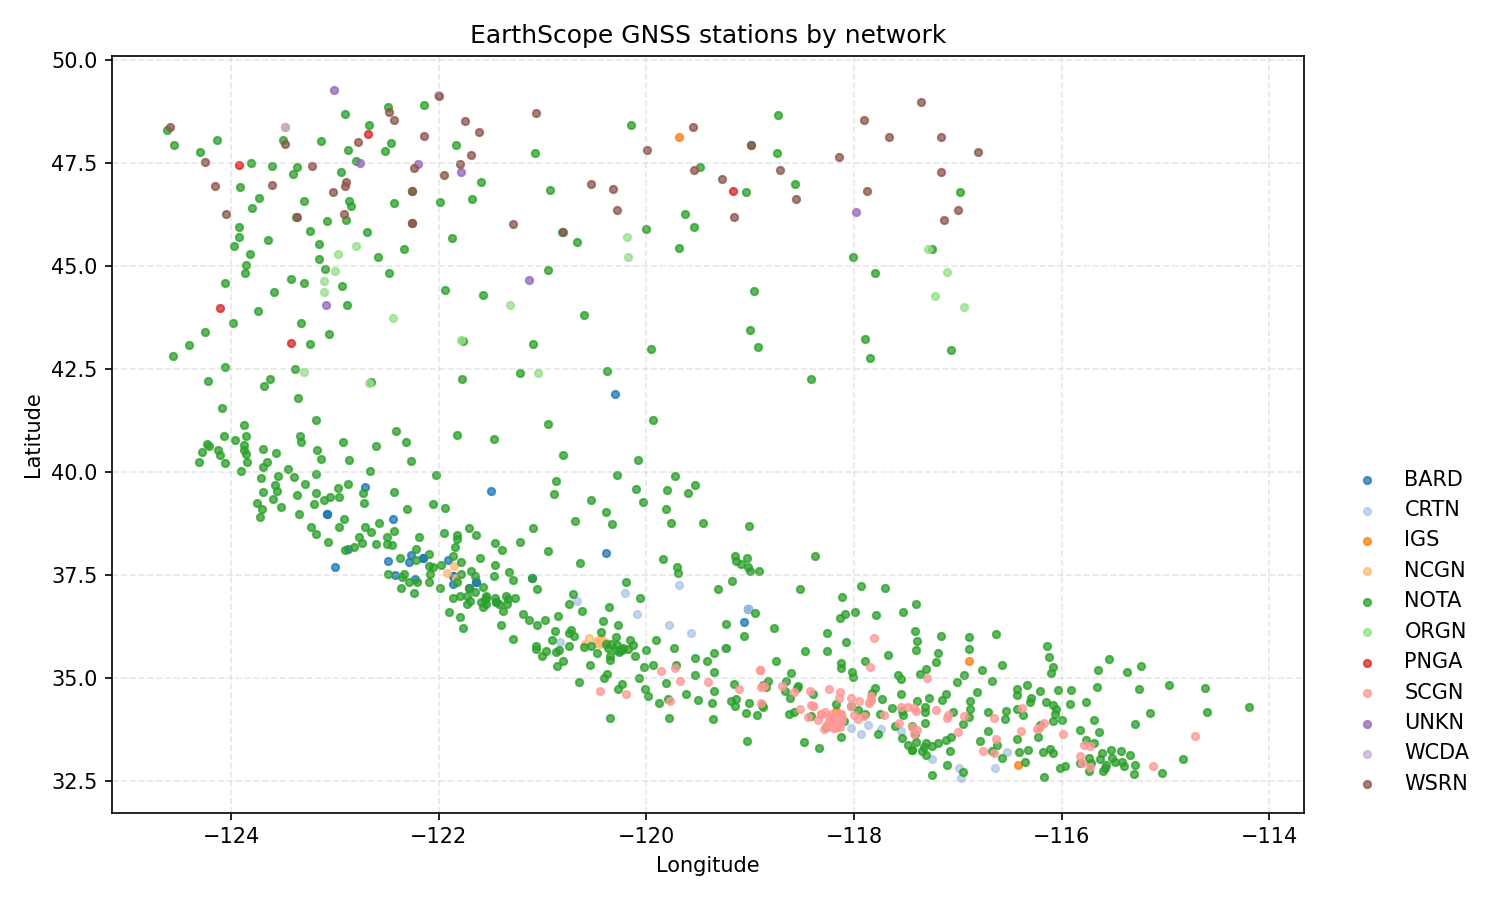

In [ ]:
# Visualize the EarthScope station coverage
from IPython.display import Image

# Invoke the function which will be executed on the remote environment
viz = plot_earthscope_stations(dataset_url, 800)

# Display results
print("Stations by network:", viz["net_counts"])
print("Stations by status:", viz["status_counts"])
Image(viz["image"])